<a href="https://colab.research.google.com/github/aditii1310/ML_Project/blob/main/Machine_learning_Project_%E2%80%9CAnalysis_of_Social_Media_Usage_and_Mental_Health_Among_Students%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Social Media Mental Health Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.upload()


Saving social media - social media.csv to social media - social media.csv


{'social media - social media.csv': b'User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity\r\nU-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.5,Gaming,Active,0,0,3.9,9,Mild,5,Mild\r\nU-e7778765,20,Male,Digital Minimalist,TikTok,0.5,Gaming,Active,0,0,5.5,0,Minimal,8,Mild\r\nU-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal\r\nU-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal\r\nU-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate\r\nU-e578c94a,18,Male,Digital Minimalist,YouTube,0.56,Entertainment/Comedy,Active,0,0,6.2,0,Minimal,2,None-Minimal\r\nU-a04da6a8,20,Female,Hyper-Connected,Facebook,6.57,Lifestyle/Fashion,Active,1,0,4.7,15,Severe,12,Moderate\r\nU-408fc4

In [3]:
import pandas as pd
df = pd.read_csv("social media - social media.csv")
df.head()

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [ ]:
df.shape

(999, 15)

In [ ]:
numerical_vars = df.select_dtypes(include=["int64","float64"]).columns
categorical_vars = df.select_dtypes(include=["object"]).columns


In [ ]:
df.isnull().sum()


,0
User_ID,0
Age,0
Gender,0
User_Archetype,0
Primary_Platform,0
Daily_Screen_Time_Hours,0
Dominant_Content_Type,0
Activity_Type,0
Late_Night_Usage,0
Social_Comparison_Trigger,0


In [ ]:
df["Age"].min()
df["Age"].max()

df[(df["Age"] < 10) | (df["Age"] > 100)]


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity


In [ ]:
df[df["Daily_Screen_Time_Hours"] > 24]


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity


In [ ]:
# GAD-7 consistency check
df[~df.apply(
    lambda x: (
        (0 <= x["GAD_7_Score"] <= 4 and x["GAD_7_Severity"]=="Minimal") or
        (5 <= x["GAD_7_Score"] <= 9 and x["GAD_7_Severity"]=="Mild") or
        (10 <= x["GAD_7_Score"] <= 14 and x["GAD_7_Severity"]=="Moderate") or
        (x["GAD_7_Score"] >= 15 and x["GAD_7_Severity"]=="Severe")
    ), axis=1
)]


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity


In [ ]:
# PHQ-9 consistency check
df[~df.apply(
    lambda x: (
        (0 <= x["PHQ_9_Score"] <= 4 and x["PHQ_9_Severity"] in ["None-Minimal","Minimal"]) or
        (5 <= x["PHQ_9_Score"] <= 9 and x["PHQ_9_Severity"]=="Mild") or
        (10 <= x["PHQ_9_Score"] <= 14 and x["PHQ_9_Severity"]=="Moderate") or
        (x["PHQ_9_Score"] >= 15 and x["PHQ_9_Severity"]=="Severe")
    ), axis=1
)]


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
10,U-52f7cdb6,18,Female,Hyper-Connected,Twitter/X,7.59,Educational/Tech,Active,1,0,3.3,10,Moderate,17,Moderately Severe
83,U-537c6e67,18,Female,Hyper-Connected,Facebook,8.10,News/Politics,Active,1,0,4.6,13,Moderate,19,Moderately Severe
98,U-f1cb72ed,18,Female,Passive Scroller,Instagram,4.35,Lifestyle/Fashion,Passive,1,1,5.2,19,Severe,17,Moderately Severe
135,U-d8b6bd2c,18,Female,Passive Scroller,LinkedIn,4.20,Lifestyle/Fashion,Passive,1,0,5.3,17,Severe,19,Moderately Severe
178,U-6b0fe0fa,19,Female,Hyper-Connected,LinkedIn,6.55,Lifestyle/Fashion,Active,1,0,3.1,9,Mild,15,Moderately Severe
213,U-9043b356,19,Female,Hyper-Connected,TikTok,8.71,Educational/Tech,Active,1,0,4.1,10,Moderate,15,Moderately Severe
222,U-4bbc8a15,20,Male,Hyper-Connected,Snapchat,8.93,Entertainment/Comedy,Active,1,0,3.9,7,Mild,18,Moderately Severe
265,U-021c5d4d,22,Male,Hyper-Connected,LinkedIn,7.54,Entertainment/Comedy,Active,1,0,4.7,10,Moderate,15,Moderately Severe
291,U-b7d1b3ec,18,Male,Hyper-Connected,Facebook,5.70,Lifestyle/Fashion,Active,1,0,5.7,10,Moderate,15,Moderately Severe
293,U-e65fca71,18,Female,Passive Scroller,Instagram,5.86,Self-Help/Motivation,Passive,1,1,4.8,16,Severe,15,Moderately Severe


In [ ]:
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})

df = pd.get_dummies(
    df,
    columns=["User_Archetype","Primary_Platform"],
    drop_first=True
)


In [ ]:
df["Late_Night_Usage"] = df["Late_Night_Usage"].map({"Yes":True,"No":False})
df["Social_Comparison_Trigger"] = df["Social_Comparison_Trigger"].map({"Yes":True,"No":False})


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [ ]:
Q1 = df["Sleep_Duration_Hours"].quantile(0.25)
Q3 = df["Sleep_Duration_Hours"].quantile(0.75)
IQR = Q3 - Q1

df[(df["Sleep_Duration_Hours"] < Q1 - 1.5*IQR) |
   (df["Sleep_Duration_Hours"] > Q3 + 1.5*IQR)]


,User_ID,Age,Gender,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,...,PHQ_9_Severity,User_Archetype_Digital Minimalist,User_Archetype_Hyper-Connected,User_Archetype_Passive Scroller,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Snapchat,Primary_Platform_TikTok,Primary_Platform_Twitter/X,Primary_Platform_YouTube
974,U-7e5793e7,19,0,1.66,Entertainment/Comedy,Active,NaN,NaN,9.9,1,...,None-Minimal,False,False,False,False,False,False,False,False,True


In [ ]:
df["High_Screen_Time"] = df["Daily_Screen_Time_Hours"].apply(
    lambda x: "Yes" if x > 6 else "No"
)


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,...,User_Archetype_Digital Minimalist,User_Archetype_Hyper-Connected,User_Archetype_Passive Scroller,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Snapchat,Primary_Platform_TikTok,Primary_Platform_Twitter/X,Primary_Platform_YouTube,High_Screen_Time


In [ ]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [ ]:
df["Late_Night_Usage"] = df["Late_Night_Usage"].map({"Yes": True, "No": False})
df["Social_Comparison_Trigger"] = df["Social_Comparison_Trigger"].map({"Yes": True, "No": False})

In [ ]:
df.columns



Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time_Hours',
       'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage',
       'Social_Comparison_Trigger', 'Sleep_Duration_Hours', 'GAD_7_Score',
       'GAD_7_Severity', 'PHQ_9_Score', 'PHQ_9_Severity',
       'User_Archetype_Digital Minimalist', 'User_Archetype_Hyper-Connected',
       'User_Archetype_Passive Scroller', 'Primary_Platform_Instagram',
       'Primary_Platform_LinkedIn', 'Primary_Platform_Snapchat',
       'Primary_Platform_TikTok', 'Primary_Platform_Twitter/X',
       'Primary_Platform_YouTube', 'High_Screen_Time'],
      dtype='object')

In [ ]:
df_raw = pd.read_csv("social media - social media.csv")


In [ ]:
df = df_raw.copy()


In [ ]:
import pandas as pd

# Load fresh dataset
df_raw = pd.read_csv("social media - social media.csv")
df = df_raw.copy()

# Remove missing values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode Gender
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# Convert binary variables
df["Late_Night_Usage"] = df["Late_Night_Usage"].map({"Yes": True, "No": False})
df["Social_Comparison_Trigger"] = df["Social_Comparison_Trigger"].map({"Yes": True, "No": False})

# One-hot encode categorical variables (ONLY ONCE)
df = pd.get_dummies(
    df,
    columns=["User_Archetype", "Primary_Platform"],
    drop_first=True
)

# Create derived feature
df["High_Screen_Time"] = df["Daily_Screen_Time_Hours"].apply(
    lambda x: "Yes" if x > 6 else "No"
)


In [ ]:
df

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,U-d7c1b542,18,Female,Hyper-Connected,Snapchat,6.93,Educational/Tech,Active,1,0,3.8,11,Moderate,9,Mild
995,U-3197fa6a,19,Male,Hyper-Connected,TikTok,7.78,Educational/Tech,Active,1,0,4.8,14,Moderate,6,Mild
996,U-8445e450,19,Male,Average User,Facebook,3.74,Self-Help/Motivation,Active,0,0,6.0,2,Minimal,0,None-Minimal
997,U-59a723c4,18,Male,Hyper-Connected,Instagram,5.54,Entertainment/Comedy,Active,0,0,6.2,6,Mild,2,None-Minimal


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("social media - social media.csv")


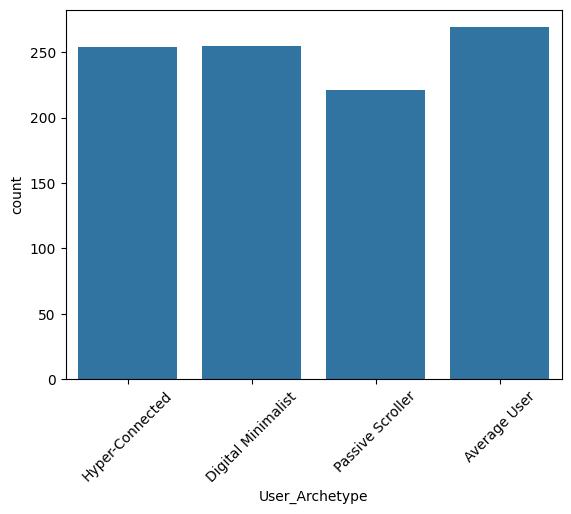

In [ ]:
df["User_Archetype"].value_counts()
sns.countplot(x="User_Archetype", data=df)
plt.xticks(rotation=45)
plt.show()


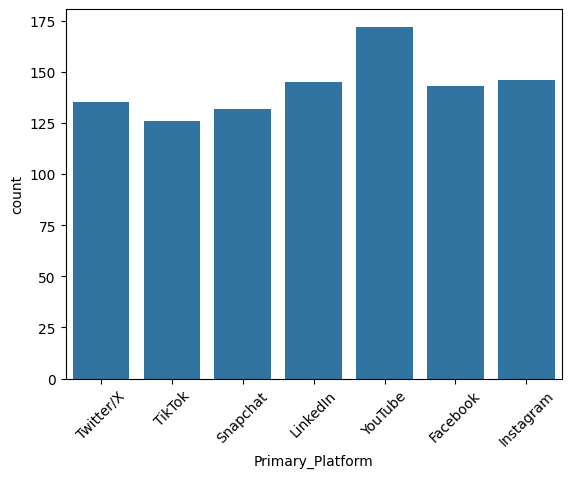

In [ ]:
df["Primary_Platform"].value_counts()
sns.countplot(x="Primary_Platform", data=df)
plt.xticks(rotation=45)
plt.show()


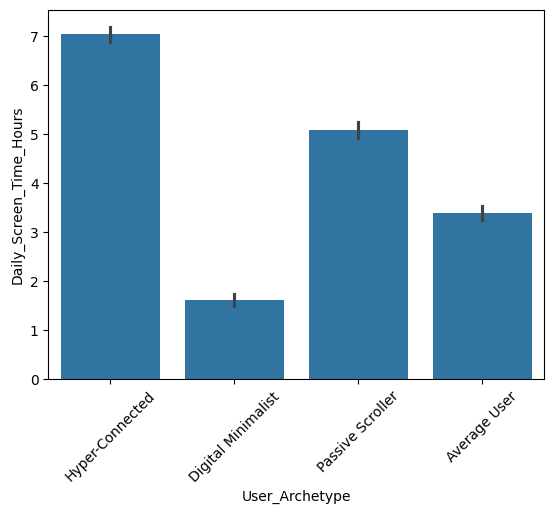

In [ ]:
df.groupby("User_Archetype")["Daily_Screen_Time_Hours"].mean()
sns.barplot(x="User_Archetype", y="Daily_Screen_Time_Hours", data=df)
plt.xticks(rotation=45)
plt.show()


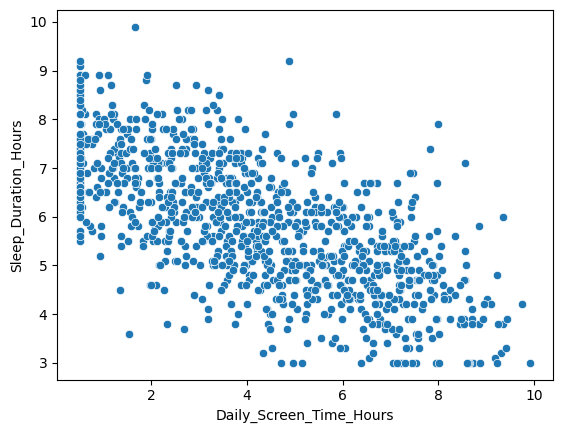

In [ ]:
sns.scatterplot(
    x="Daily_Screen_Time_Hours",
    y="Sleep_Duration_Hours",
    data=df
)
plt.show()


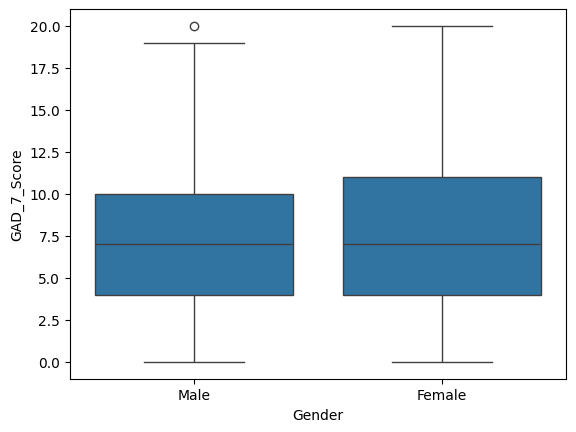

In [ ]:
df.groupby("Gender")["GAD_7_Score"].mean()
sns.boxplot(x="Gender", y="GAD_7_Score", data=df)
plt.show()


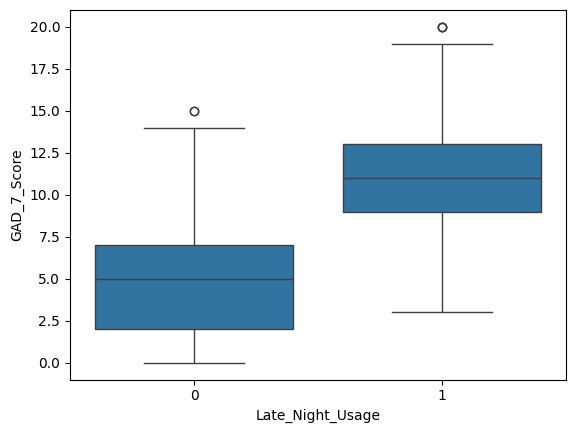

In [ ]:
df.groupby("Late_Night_Usage")["GAD_7_Score"].mean()
sns.boxplot(x="Late_Night_Usage", y="GAD_7_Score", data=df)
plt.show()


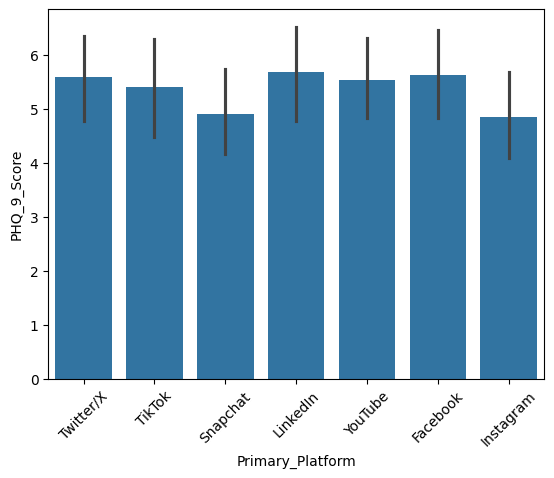

In [ ]:
df.groupby("Primary_Platform")["PHQ_9_Score"].mean()
sns.barplot(x="Primary_Platform", y="PHQ_9_Score", data=df)
plt.xticks(rotation=45)
plt.show()




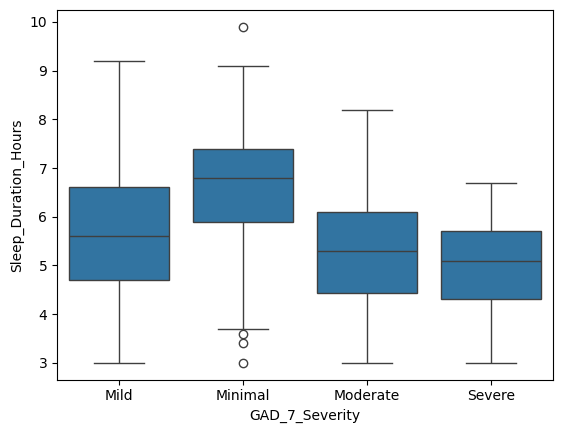

In [ ]:
sns.boxplot(
    x="GAD_7_Severity",
    y="Sleep_Duration_Hours",
    data=df
)
plt.show()


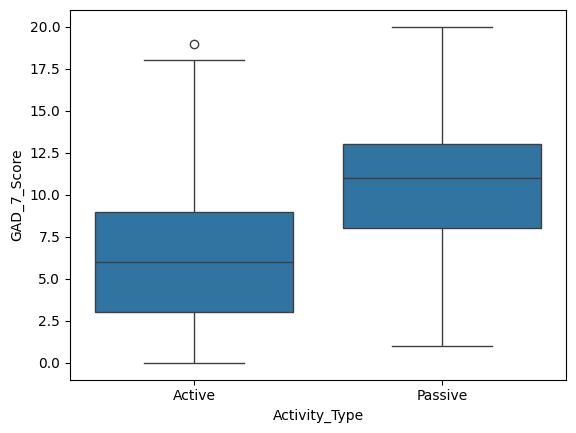

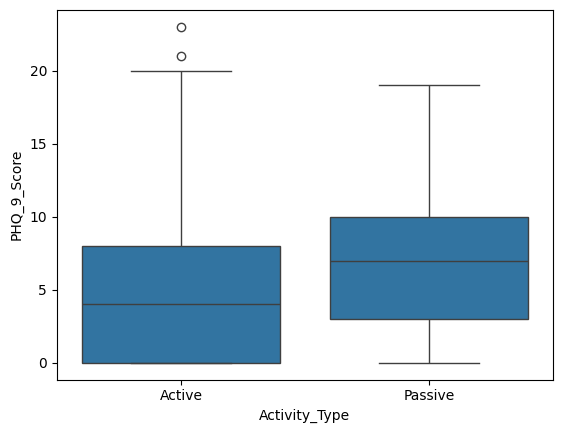

In [ ]:
df.groupby("Activity_Type")[["GAD_7_Score","PHQ_9_Score"]].mean()
sns.boxplot(x="Activity_Type", y="GAD_7_Score", data=df)
plt.show()

sns.boxplot(x="Activity_Type", y="PHQ_9_Score", data=df)
plt.show()


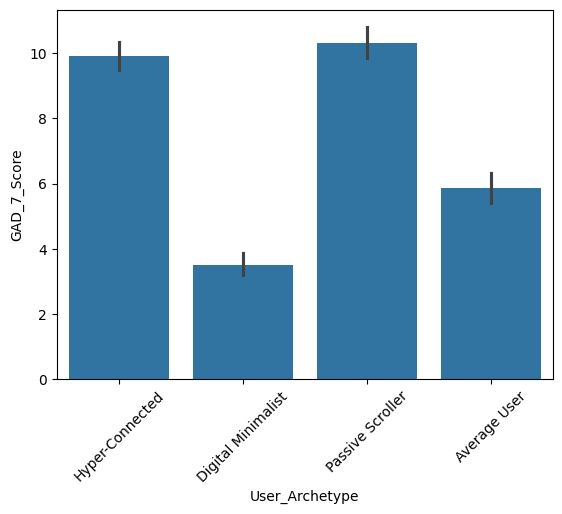

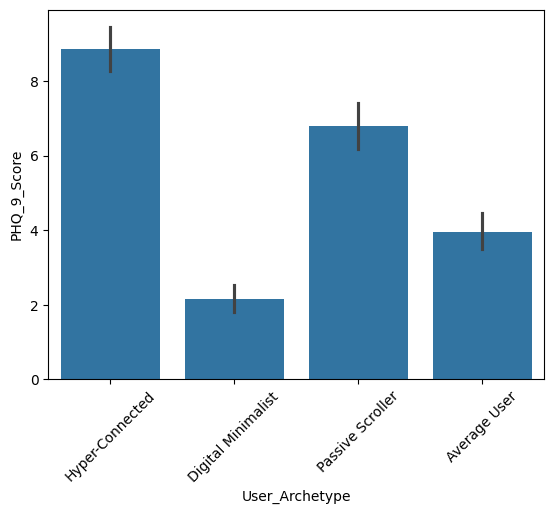

In [ ]:
df.groupby("User_Archetype")[["GAD_7_Score","PHQ_9_Score"]].mean()
sns.barplot(x="User_Archetype", y="GAD_7_Score", data=df)
plt.xticks(rotation=45)
plt.show()

sns.barplot(x="User_Archetype", y="PHQ_9_Score", data=df)
plt.xticks(rotation=45)
plt.show()


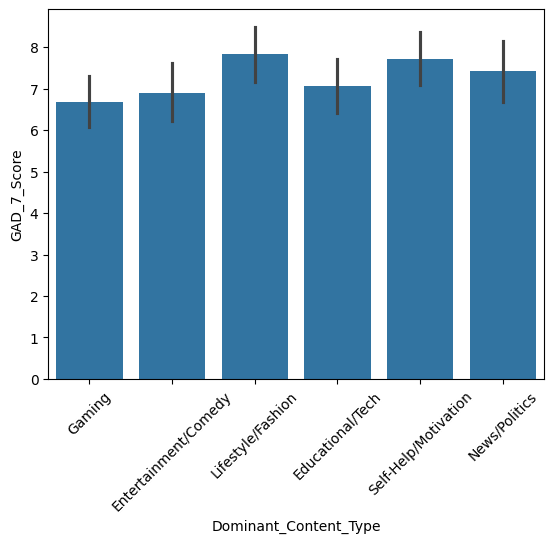

In [ ]:
df.groupby("Dominant_Content_Type")[["GAD_7_Score","PHQ_9_Score"]].mean()
sns.barplot(x="Dominant_Content_Type", y="GAD_7_Score", data=df)
plt.xticks(rotation=45)
plt.show()


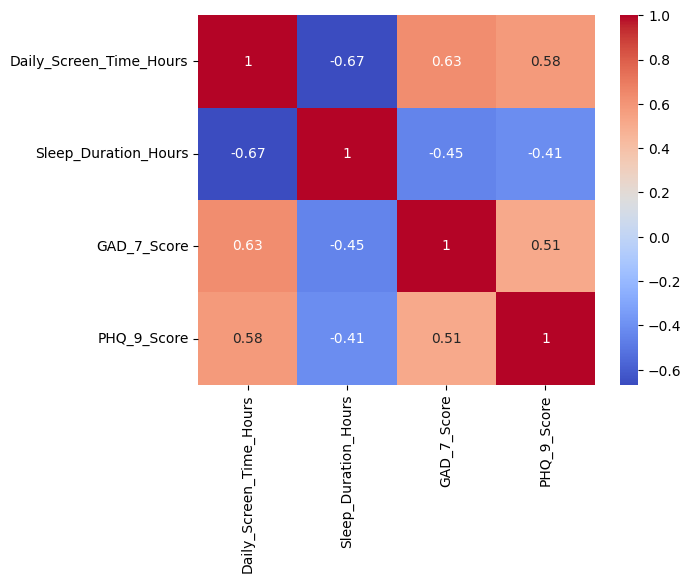

In [ ]:
corr = df[
    ["Daily_Screen_Time_Hours",
     "Sleep_Duration_Hours",
     "GAD_7_Score",
     "PHQ_9_Score"]
].corr()

corr
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


In [4]:
y = df['GAD_7_Severity']


In [6]:
X = df.drop(['GAD_7_Severity'], axis=1)



In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)


ValueError: could not convert string to float: 'U-6bbf6a4b'

In [11]:
df = df.drop('User_ID', axis=1)


In [12]:
df['GAD_7_Severity'] = df['GAD_7_Severity'].map({
    'Minimal':0,
    'Mild':1,
    'Moderate':2,
    'Severe':3
})


In [13]:
X = df.drop('GAD_7_Severity', axis=1)
y = df['GAD_7_Severity']


In [14]:
X = pd.get_dummies(X, drop_first=True)


In [15]:
X.dtypes


,0
Age,int64
Daily_Screen_Time_Hours,float64
Late_Night_Usage,int64
Social_Comparison_Trigger,int64
Sleep_Duration_Hours,float64
GAD_7_Score,int64
PHQ_9_Score,int64
Gender_Male,bool
User_Archetype_Digital Minimalist,bool
User_Archetype_Hyper-Connected,bool


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))


RF Accuracy: 0.975
